In [2]:
import pm4py
import pandas as pd
from pm4py.objects.log.importer.xes import importer as xes_importer
from collections import Counter
import Functions as fk
import numpy as np
import json


from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_pinball_loss

In [3]:
log = xes_importer.apply("/Users/simonimmler/PycharmProjects/Praktikum/data/BPI Challenge 2017.xes")

parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

# Basic Analytics: 

In [4]:
ts = [e["time:timestamp"] for t in log for e in t if "time:timestamp" in e]
ts = pd.to_datetime(ts, utc=True, errors="coerce")
print("missing ts:", ts.isna().sum())
print("min ts:", ts.min())

print("max ts:", ts.max())

missing ts: 0
min ts: 2016-01-01 09:51:15.304000+00:00
max ts: 2017-02-01 14:11:03.499000+00:00



Different Lifecycle states

In [5]:
lcs = [e.get("lifecycle:transition", "missing") for t in log for e in t]
print(Counter(lcs).most_common(10))


[('complete', 475306), ('suspend', 215402), ('schedule', 149104), ('start', 128227), ('resume', 127160), ('ate_abort', 85224), ('withdraw', 21844)]


In [6]:
df = pm4py.convert_to_dataframe(log)
cols = df["lifecycle:transition"].dropna().unique()
cols


array(['complete', 'schedule', 'withdraw', 'start', 'suspend',
       'ate_abort', 'resume'], dtype=object)

In [7]:
states_per_act = (
    df.groupby("concept:name")["lifecycle:transition"]
      .apply(lambda s: sorted(set(s.dropna())))
      .reset_index(name="lifecycle_states")
)
states_per_act


,concept:name,lifecycle_states
0,A_Accepted,[complete]
1,A_Cancelled,[complete]
2,A_Complete,[complete]
3,A_Concept,[complete]
4,A_Create Application,[complete]
5,A_Denied,[complete]
6,A_Incomplete,[complete]
7,A_Pending,[complete]
8,A_Submitted,[complete]
9,A_Validating,[complete]


Calculate the Event duration for each trace (I use the total span time for each activtiy meaning the total processing time is (timestamp last occurrence in the trace) - (timestamp first occurence in the trace) 

In [8]:
span = (df.dropna(subset=["time:timestamp"]).groupby(["case:concept:name", "concept:name"])["time:timestamp"].agg(act_first_ts="min", act_last_ts="max").reset_index())
span["act_duration_seconds"] = (span["act_last_ts"] - span["act_first_ts"]).dt.total_seconds()

# merge for each Application (case:concept:name) and for each Activity of that case (concept:name)
df_dur = df.merge(span, on=["case:concept:name", "concept:name"], how="left")
df_dur.head(20)

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,...,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID,act_first_ts,act_last_ts,act_duration_seconds
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:51:15.304000+00:00,2016-01-01 09:51:15.304000+00:00,0.000
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:51:15.352000+00:00,2016-01-01 09:51:15.352000+00:00,0.000
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:51:15.774000+00:00,2016-01-01 09:52:36.392000+00:00,80.618
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:51:15.774000+00:00,2016-01-01 09:52:36.392000+00:00,80.618
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:52:36.403000+00:00,2016-01-02 11:30:28.621000+00:00,92272.218
5,statechange,User_1,A_Concept,Application,ApplState_642383566,complete,2016-01-01 09:52:36.413000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:52:36.413000+00:00,2016-01-01 09:52:36.413000+00:00,0.000
6,Obtained,User_17,W_Complete application,Workflow,Workitem_1875340971,start,2016-01-02 10:45:22.429000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:52:36.403000+00:00,2016-01-02 11:30:28.621000+00:00,92272.218
7,Released,User_17,W_Complete application,Workflow,Workitem_1452291795,suspend,2016-01-02 10:49:28.816000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:52:36.403000+00:00,2016-01-02 11:30:28.621000+00:00,92272.218
8,statechange,User_52,A_Accepted,Application,ApplState_99568828,complete,2016-01-02 11:23:04.299000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-02 11:23:04.299000+00:00,2016-01-02 11:23:04.299000+00:00,0.000
9,Created,User_52,O_Create Offer,Offer,Offer_148581083,complete,2016-01-02 11:29:03.994000+00:00,Existing loan takeover,New credit,Application_652823628,...,44.0,True,498.29,True,979.0,20000.0,NaN,2016-01-02 11:29:03.994000+00:00,2016-01-02 11:29:03.994000+00:00,0.000


# Processing Times for W_ Activities

Calculate the processing times for all activities, that have more than 1 lifecycle transitions  -> all others have no real working time

In [9]:
from processing_times.basic_analysis import (
    build_segments_and_instances, build_instance_times,
    add_occurrence_features, add_time_features, add_case_context
)

seg, proc_inst = build_segments_and_instances(df, workflow_only=True)
inst = build_instance_times(seg, proc_inst)

inst = add_occurrence_features(inst)          # -> occ_idx, occ_log
inst = add_time_features(inst, ts_col="inst_start")  # -> tod_sin, tod_cos, weekday
inst = add_case_context(inst, df, ctx_cols=("case:ApplicationType", "case:RequestedAmount"), strict=False)


In [10]:
inst[inst["concept:name"]=="W_Assess potential fraud"]["proc_seconds"].describe()


count       324.000000
mean       8035.435398
std       16924.623661
min           3.903000
25%          92.438500
50%         684.986000
75%        5861.768500
max      122669.588000
Name: proc_seconds, dtype: float64

Are there any traces that have actually multiple loops from start - complete

In [11]:
inst.groupby(["concept:name"])["instance"].max().sort_values(ascending=False)


concept:name
W_Validate application      8
W_Call incomplete files     6
W_Assess potential fraud    2
W_Call after offers         2
W_Complete application      2
W_Handle leads              2
Name: instance, dtype: int64

Note: I only use this duration because our simulator does only include lifecycle transitions of start and complete. If i would only use the "real" processing times the durations would be too small

In [12]:
from processing_times.basic_analysis import build_duration_counts
durations_full_proc = build_duration_counts(inst, value_col="proc_seconds", drop_zeros=True, round_to=0.01)
durations_full_total = build_duration_counts(inst, value_col="total_seconds", drop_zeros=True, round_to=0.01)

durations_full_wait_pos = build_duration_counts(inst, value_col="wait_seconds", drop_zeros=False, round_to=0.01)

print("W_ activities in durations_full_proc:", len(durations_full_proc))
print("W_ activities in durations_full_total:", len(durations_full_total))
print("W_ activities in durations_full_wait_pos:", len(durations_full_wait_pos))



W_ activities in durations_full_proc: 6
W_ activities in durations_full_total: 6
W_ activities in durations_full_wait_pos: 6


In [13]:
acts_total = set(durations_full_total.keys())
acts_proc  = set(durations_full_proc.keys())
extra_acts = sorted(list(acts_total - acts_proc))

print("Extra acts (total but not proc):", extra_acts)


Extra acts (total but not proc): []


In [14]:
cols = ["case:concept:name", "concept:name", "instance", "inst_start", "inst_end",
        "total_seconds", "proc_seconds", "wait_seconds"]

inst.loc[inst["concept:name"].isin(extra_acts), cols]


,case:concept:name,concept:name,instance,inst_start,inst_end,total_seconds,proc_seconds,wait_seconds


# O_ and A_ Activities

The event log does not give information about processing times of technical activities, but it would be realistic that there is a little bit of a buffer between those activities

calculate active time for each activity

In [15]:
events = seg["concept:name"].value_counts()
events

concept:name
W_Validate application        72932
W_Call incomplete files       62256
W_Call after offers           60560
W_Complete application        52321
W_Handle leads                 4891
W_Assess potential fraud       1320
W_Shortened completion           81
W_Personal Loan collection        9
Name: count, dtype: int64

In [16]:
events = df["concept:name"].value_counts()
events

concept:name
W_Validate application        209496
W_Call after offers           191092
W_Call incomplete files       168529
W_Complete application        148900
W_Handle leads                 47264
O_Create Offer                 42995
O_Created                      42995
O_Sent (mail and online)       39707
A_Validating                   38816
A_Create Application           31509
A_Concept                      31509
A_Accepted                     31509
A_Complete                     31362
O_Returned                     23305
A_Incomplete                   23055
O_Cancelled                    20898
A_Submitted                    20423
O_Accepted                     17228
A_Pending                      17228
A_Cancelled                    10431
O_Refused                       4695
A_Denied                        3753
W_Assess potential fraud        3282
O_Sent (online only)            2026
W_Shortened completion           238
W_Personal Loan collection        22
Name: count, dtype: int64

# Fit the models

Fit parametric models for processing times and full durations

In [17]:
from processing_times.basic_analysis import  fit_parametric_models

processing_models_wait = {} # leave this out because of empiciral sampling in next cell
processing_models_proc = fit_parametric_models(durations_full_proc)
processing_models_total = fit_parametric_models(durations_full_total)
print("Built proc models for:", len(processing_models_proc), "activities")
print("Built total models for:", len(processing_models_total), "activities")
print("Built wait models (positive-part + p0) for:", len(processing_models_wait), "activities")


Built proc models for: 6 activities
Built total models for: 6 activities
Built wait models (positive-part + p0) for: 0 activities


Ensure that we have no zero infaltion

In [18]:
p0_global = float((inst["total_seconds"] <= 0.0).mean())
p0_global

0.0

In [19]:
import pandas as pd
import numpy as np

def median_time_to_next_event_by_activity(
    df,
    case_col="case:concept:name",
    act_col="concept:name",
    ts_col="time:timestamp",
    clip_negative=True,
    clip_max=7*24*3600,   # cap at 7 days to avoid extreme gaps
):
    d = df[[case_col, act_col, ts_col]].copy()
    d[ts_col] = pd.to_datetime(d[ts_col], utc=True, errors="coerce")
    d = d.dropna(subset=[case_col, act_col, ts_col])

    d = d.sort_values([case_col, ts_col])
    d["next_ts"] = d.groupby(case_col)[ts_col].shift(-1)

    dt = (d["next_ts"] - d[ts_col]).dt.total_seconds()
    if clip_negative:
        dt = dt.clip(lower=0)
    if clip_max is not None:
        dt = dt.clip(upper=float(clip_max))

    d["dt_next"] = dt
    d = d.dropna(subset=["dt_next"])

    per_act = d.groupby(act_col)["dt_next"].median().astype(float).to_dict()
    global_med = float(d["dt_next"].median()) if len(d) else 0.2
    return per_act, global_med




# Fill the models with A_ and O_ Activities

In [20]:
# --- Add const models for missing activities (A_ / O_ etc.) ---

all_acts = sorted(set(df["concept:name"]))
per_act_med_dt, global_med_dt = median_time_to_next_event_by_activity(df)
wait_sampling ={}


for act in all_acts:
    if act not in processing_models_total:
        v = float(per_act_med_dt.get(act, global_med_dt))
        processing_models_total[act] = {"dist": "const", "value": float(v)}



    if act not in processing_models_total:
        processing_models_total[act] = {"dist": "const", "value": 0.0}
    if act not in processing_models_wait:
        # if there are no waiting observations, default to 0 waiting time
        if act.startswith("W_") and act in durations_full_wait_pos:
            # empirical waiting distribution (counts format)
            processing_models_wait[act] = {
                "dist": "empirical",
                "counts": durations_full_wait_pos[act]   # [(count, value), ...]
            }
        else:
            # fallback: median time-to-next-event (constant)
            v = float(per_act_med_dt.get(act, global_med_dt))
            processing_models_wait[act] = {
                "dist": "const",
                "value": float(v)  # min 1s to avoid identical timestamps
            }

# Backward compatible
processing_models = processing_models_proc
print(processing_models_wait.get("W_Assess potential fraud"))
print(processing_models_proc.get("A_Create Application"))



{'dist': 'empirical', 'counts': [(44, 0.0), (1, 17.0), (1, 29.78), (1, 49.06), (1, 93.26), (1, 171.9), (1, 208.92000000000002), (1, 354.46), (1, 397.89), (1, 448.37), (1, 529.13), (1, 722.75), (1, 788.84), (1, 983.84), (1, 1059.95), (1, 1454.08), (1, 1751.6000000000001), (1, 2097.48), (1, 2170.0), (1, 2465.59), (1, 2469.59), (1, 2475.27), (1, 2502.55), (1, 2579.4500000000003), (1, 3538.86), (1, 4053.23), (1, 4137.91), (1, 4430.68), (1, 4617.9400000000005), (1, 5643.32), (1, 5668.32), (1, 5686.74), (1, 5761.37), (1, 6052.81), (1, 6069.06), (1, 6089.51), (1, 6187.400000000001), (1, 6268.8), (1, 6474.74), (1, 6483.39), (1, 6973.0), (1, 7049.53), (1, 7319.110000000001), (1, 7354.400000000001), (1, 7395.17), (1, 7530.57), (1, 7794.08), (1, 7859.110000000001), (1, 8041.110000000001), (1, 8068.05), (1, 8897.07), (1, 9291.51), (1, 9393.79), (1, 9923.210000000001), (1, 10102.02), (1, 10534.06), (1, 10871.18), (1, 12091.07), (1, 12184.07), (1, 13073.07), (1, 13078.98), (1, 13179.380000000001), (

W_Call after offers {'dist': 'lognorm', 'params': {'s': 1.015352214234354, 'scale': 195.1413487212624}}
[np.float64(122.35657454254726), np.float64(270.13874180155665), np.float64(154.2170443923966), np.float64(222.69430790442016), np.float64(63.37398472046033), np.float64(94.41133326850893), np.float64(271.00545976607117), np.float64(193.27200951019495), np.float64(165.7811385249413), np.float64(81.44993134800055)]


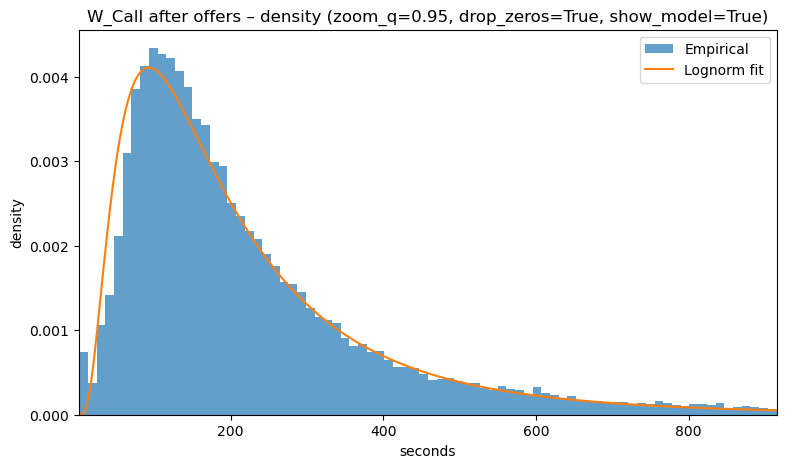

W_Complete application {'dist': 'gamma', 'params': {'a': 1.2032586004343957, 'scale': 546.5539873138229}}
[np.float64(41.80402583169097), np.float64(400.39051086436757), np.float64(111.22711797327592), np.float64(100.05332107378312), np.float64(207.54513433167105), np.float64(602.5323123043091), np.float64(549.8870323752609), np.float64(817.4334148027613), np.float64(134.3000816241003), np.float64(2439.3770439500886)]


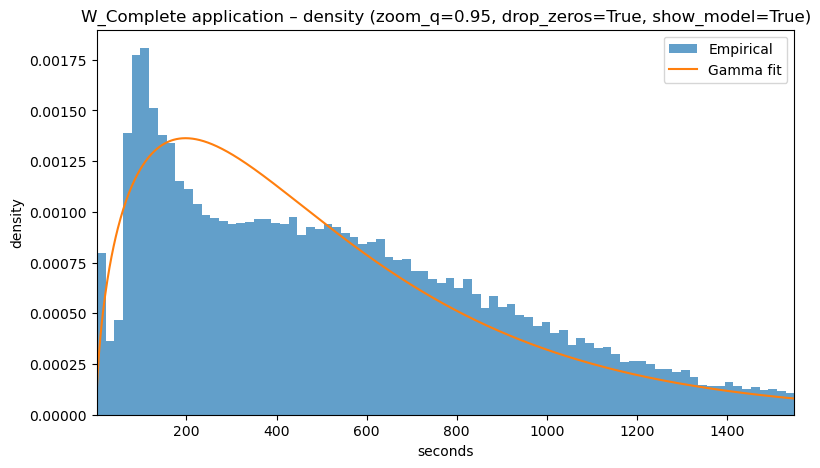

W_Validate application {'dist': 'lognorm', 'params': {'s': 1.7842284678095217, 'scale': 234.0366582310631}}
[np.float64(99.91036858689938), np.float64(672.9479329797673), np.float64(50.759636137823556), np.float64(35.65324388319638), np.float64(122.07785244836462), np.float64(1065.116170629784), np.float64(571.8766798288755), np.float64(207.21054233602263), np.float64(378.65011297729984), np.float64(545.2332462580597)]


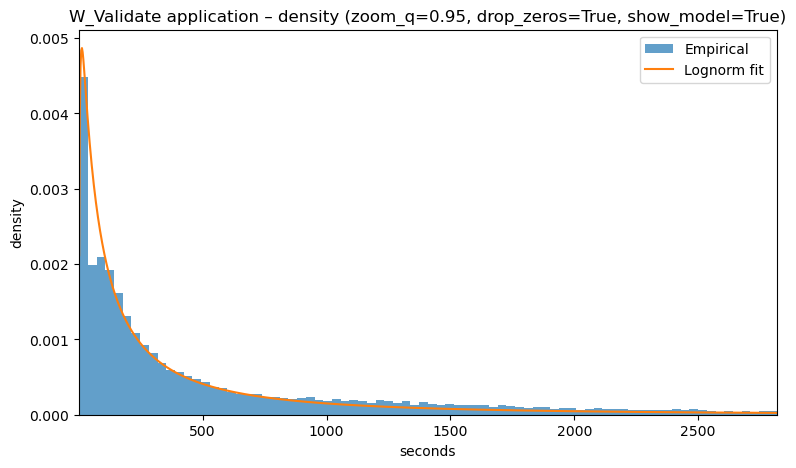

W_Call incomplete files {'dist': 'lognorm', 'params': {'s': 1.143981187006498, 'scale': 296.87727400960046}}
[np.float64(151.96129772690426), np.float64(1296.4489646286843), np.float64(130.6922714707282), np.float64(183.1434426952569), np.float64(633.207646421935), np.float64(1101.3011279473667), np.float64(152.2792025773897), np.float64(269.6210269226633), np.float64(93.62045397790271), np.float64(413.54065238146086)]


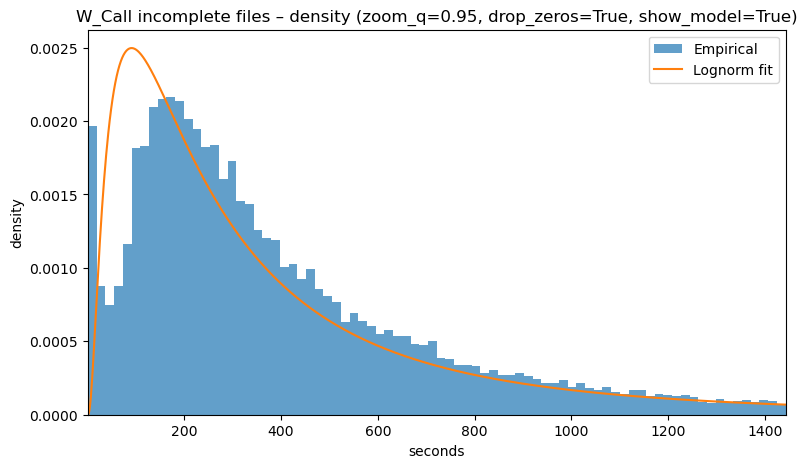

W_Handle leads {'dist': 'lognorm', 'params': {'s': 1.095259783616382, 'scale': 82.15536142828658}}
[np.float64(157.65207957408742), np.float64(18.793784271831626), np.float64(32.63787535279489), np.float64(208.08945801756775), np.float64(74.50622498589104), np.float64(94.4779527747746), np.float64(489.31949643354), np.float64(55.71841008229844), np.float64(149.0910235046729), np.float64(33.21604647046352)]


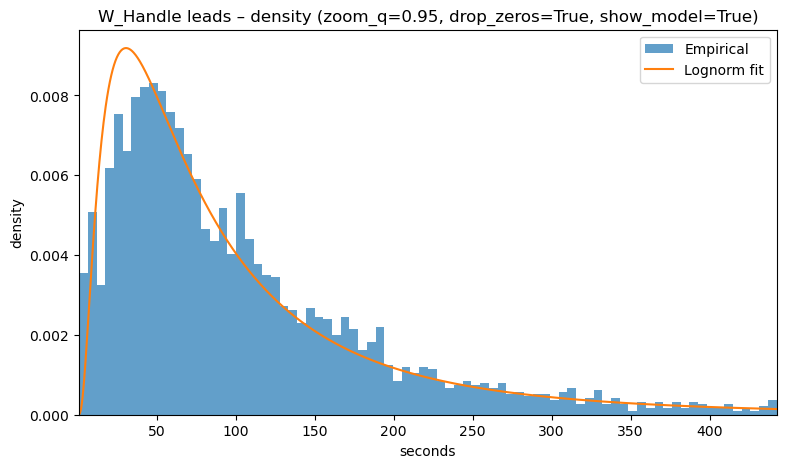

W_Assess potential fraud {'dist': 'lognorm', 'params': {'s': 2.5046392183730126, 'scale': 751.0363907467519}}
[np.float64(64.13552849645629), np.float64(40.82154579850453), np.float64(234.53376814626867), np.float64(12.813728707799438), np.float64(27005.368044727256), np.float64(230.66581833278664), np.float64(33126.651295127296), np.float64(2478.817942539425), np.float64(500.92866823364443), np.float64(1824337.3960357662)]


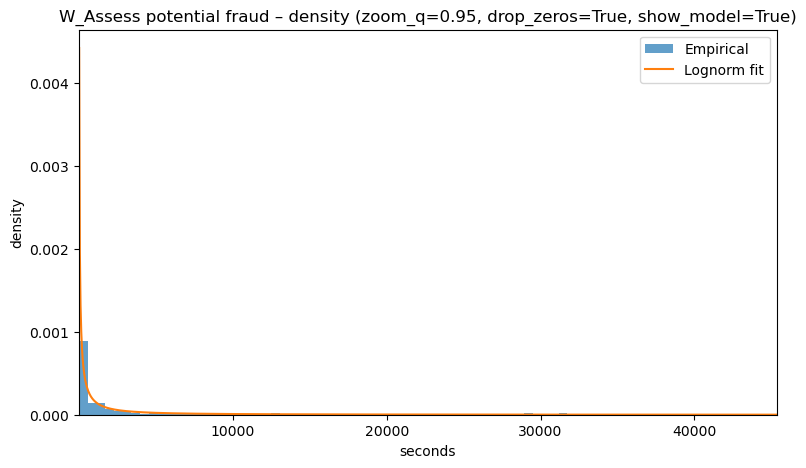

In [21]:
# --- Quick inspection / plots (optional) ---
# WARNING: plotting all activities can be slow.
# Choose which target you want to inspect:
which = "proc"  # "proc" | "total" | "wait"
N = 10  # how many activities to inspect

if which == "proc":
    models = processing_models_proc
    durs = durations_full_proc
elif which == "total":
    models = processing_models_total
    durs = durations_full_total
elif which == "wait":
    models = processing_models_wait
    durs = durations_full_wait_pos
else:
    raise ValueError("which must be 'proc', 'total', or 'wait'")

for act in list(models.keys())[:N]:
    spec = models[act]
    print(act, spec)
    print(fk.sample_processing_time(spec, n=10))
    # For wait we fitted positive-part, so drop_zeros=True is correct
    fk.density_plot_from_counts(
        durs, act,
        show_model=(spec.get("dist") in {"gamma", "lognorm"}),
        dist=spec.get("dist", "gamma"),
        drop_zeros=True,
        zoom_q=0.95
    )


In [22]:
from processing_times.basic_analysis import save_json
save_json(processing_models_wait, "wait_reference.json")
save_json(processing_models_proc, "processing_models_proc.json")
save_json(processing_models_total, "processing_models_full_dur.json")

Point Estimator (maybe I need more features for this, ask in tut)

In [23]:


X = inst[["concept:name"]].astype(str)
y = inst["proc_seconds"].astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y)

pipe = Pipeline([
    ("pre", ColumnTransformer([("cat", OneHotEncoder(handle_unknown="error"), ["concept:name"])])),
    ("model", RandomForestRegressor()),
])
pipe.fit(X_train, y_train)
print(mean_absolute_error(y_test, pipe.predict(X_test)))
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

pred = pipe.predict(X_test)
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2:", r2_score(y_test, pred))



671.4393885418436
RMSE: 2340.246029059147
R2: 0.007136484397084253


# Quantile Regression

In [24]:
from processing_times.quantile_regression import fit_and_eval_quantiles, baseline_empirical_by_activity
inst

,case:concept:name,concept:name,instance,proc_seconds,inst_start,inst_end,total_seconds,wait_seconds,occ_idx,occ_log,minute_of_day,tod_sin,tod_cos,weekday,case:ApplicationType,case:RequestedAmount,req_log
0,Application_1000086665,W_Call after offers,0,129.277,2016-08-05 14:01:23.286000+00:00,2016-08-09 18:25:32.629000+00:00,361449.343,361320.066,0,0.0,841.0,-0.503774,-0.863836,4.0,New credit,5000.0,8.517393
1,Application_1000086665,W_Complete application,0,642.724,2016-08-04 13:39:29.557000+00:00,2016-08-04 13:50:12.281000+00:00,642.724,0.000,0,0.0,819.0,-0.418660,-0.908143,3.0,New credit,5000.0,8.517393
2,Application_1000158214,W_Call after offers,0,115.307,2016-06-06 08:16:46.890000+00:00,2016-06-06 08:18:42.197000+00:00,115.307,0.000,0,0.0,496.0,0.829038,-0.559193,0.0,New credit,12500.0,9.433564
3,Application_1000158214,W_Complete application,0,870.320,2016-06-06 08:02:16.549000+00:00,2016-06-06 08:16:46.869000+00:00,870.320,0.000,0,0.0,482.0,0.861629,-0.507538,0.0,New credit,12500.0,9.433564
4,Application_1000158214,W_Validate application,0,93.137,2016-06-09 09:54:35.628000+00:00,2016-06-09 09:56:08.765000+00:00,93.137,0.000,0,0.0,594.0,0.522499,-0.852640,3.0,New credit,12500.0,9.433564
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127081,Application_999993467,W_Validate application,0,2405.429,2016-07-13 14:26:03.551000+00:00,2016-07-19 11:03:45.120000+00:00,506261.569,503856.140,0,0.0,866.0,-0.594823,-0.803857,2.0,Limit raise,10000.0,9.210440
127082,Application_999993812,W_Call after offers,0,61.874,2016-10-10 12:47:12.423000+00:00,2016-10-14 08:18:57.232000+00:00,329504.809,329442.935,0,0.0,767.0,-0.203642,-0.979045,0.0,New credit,30000.0,10.308986
127083,Application_999993812,W_Call incomplete files,0,156.698,2016-10-19 12:44:29.291000+00:00,2016-10-20 08:21:59.667000+00:00,70650.376,70493.678,0,0.0,764.0,-0.190809,-0.981627,2.0,New credit,30000.0,10.308986
127084,Application_999993812,W_Complete application,0,447.742,2016-10-07 09:38:21.802000+00:00,2016-10-07 09:45:49.544000+00:00,447.742,0.000,0,0.0,578.0,0.580703,-0.814116,4.0,New credit,30000.0,10.308986


### A) Quantile Regression for **processing time** (`proc_seconds`)

In [25]:

cat_cols = ["concept:name", "case:ApplicationType"]
num_cols = ["tod_sin", "tod_cos", "instance", "weekday", "minute_of_day", "case:RequestedAmount"]


res_proc = fit_and_eval_quantiles(inst, target="proc_seconds", cat_cols=cat_cols, num_cols=num_cols)

res_proc["cat_cols"] = cat_cols
res_proc["num_cols"] = num_cols

# baseline (empirical by activity)
baseline_empirical_by_activity(
    res_proc["X_train"], res_proc["y_train"], res_proc["X_test"], res_proc["y_test"], act_col="concept:name"
)


Coverage [q10,q90] (target ~0.80): 0.7996301833346448
Avg interval width (sec): 1205.2572561220338
Pinball loss q10/q50/q90: 63.67887798459881 264.8931699880568 284.221645104855
BASELINE Coverage [q10,q90]: 0.8017940042489574
BASELINE Avg width: 1259.2393226453694
BASELINE Pinball q10/q50/q90: 64.4964442194508 268.43317645959553 289.80272248524665


{'qs': (0.1, 0.5, 0.9),
 'coverage': 0.8017940042489574,
 'avg_width': 1259.2393226453694,
 'pin10': 64.4964442194508,
 'pin50': 268.43317645959553,
 'pin90': 289.80272248524665}

### B) Quantile Regression for **waiting/idle time** (`wait_seconds`)

In [26]:
res_wait = fit_and_eval_quantiles(inst, "wait_seconds", cat_cols, num_cols, qs=(0.10,0.50,0.90))
base_wait = baseline_empirical_by_activity(res_wait["X_train"], res_wait["y_train"],
                                           res_wait["X_test"], res_wait["y_test"],
                                           act_col="concept:name", qs=(0.10,0.50,0.90))


Coverage [q10,q90] (target ~0.80): 0.9033755606263278
Avg interval width (sec): 297279.749500306
Pinball loss q10/q50/q90: 14333.254790176255 45745.19856360942 47537.903000117876
BASELINE Coverage [q10,q90]: 0.8844519631757023
BASELINE Avg width: 328001.7401920135
BASELINE Pinball q10/q50/q90: 14332.948178857503 46958.83646374616 50212.874295619644


In [27]:
import joblib

def save_quantile_bundle(res, path="proc_qr_bundle.joblib"):
    bundle = {
        "qs": res["qs"],
        "models": res["models"],   # dict: quantile -> fitted Pipeline
        "meta": {
            "target": "proc_seconds",
            "cat_cols": ["concept:name", "case:ApplicationType"],
            "num_cols": ["tod_sin", "tod_cos", "instance", "weekday", "minute_of_day", "case:RequestedAmount"],
        },
    }
    joblib.dump(bundle, path)
    print("saved:", path)

save_quantile_bundle(res_proc, "proc_qr_bundle.joblib")


saved: proc_qr_bundle.joblib


In [28]:
from processing_times.sampling import ProcessingTimeSampler
from datetime import datetime

sampler = ProcessingTimeSampler.from_paths(
    proc_json="processing_models_proc.json",
    wait_json="wait_reference.json",
    total_json="processing_models_full_dur.json",
    qr_joblib={"proc": "proc_qr_bundle.joblib"},  # optional
    seed=42
)

now = datetime.now()
print("proc:", sampler.sample("W_Validate application", kind="proc", now=now, instance=0))
print("wait:", sampler.sample("W_Validate application", kind="wait", now=now, instance=0))
print("total:", sampler.sample("W_Validate application", kind="total", now=now, instance=0))
print("proc (QR):", sampler.sample("W_Validate application", kind="proc", now=now, instance=0, use_qr=True))


proc: 403.0911239959852
wait: 89796.16
total: 4662.002982327578
proc (QR): 656.8947627980389


In [29]:
import sklearn
print(sklearn.__version__)

1.7.2
